In [2]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
print("Loading data for evaluation...")
df = pd.read_csv('../data/processed/heart_cleaned.csv')

X = df.drop(columns=['target'])
y = df['target']

# We only need the test data for evaluation
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Loading data for evaluation...


In [4]:
print("Loading saved models and scaler...")
scaler = joblib.load('../models/scaler.pkl')
log_reg = joblib.load('../models/logistic_model.pkl')
rf_model = joblib.load('../models/rf_model.pkl')
xgb_model = joblib.load('../models/xgb_model.pkl')

# Scale the test data using Samuel's saved scaler
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

Loading saved models and scaler...


In [5]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}\n")

# Get predictions from all three models
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Print the results
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

--- Logistic Regression Performance ---
Accuracy:  0.7869
Precision: 0.7632
Recall:    0.8788
F1 Score:  0.8169

--- Random Forest Performance ---
Accuracy:  0.8361
Precision: 0.7949
Recall:    0.9394
F1 Score:  0.8611

--- XGBoost Performance ---
Accuracy:  0.7869
Precision: 0.7500
Recall:    0.9091
F1 Score:  0.8219



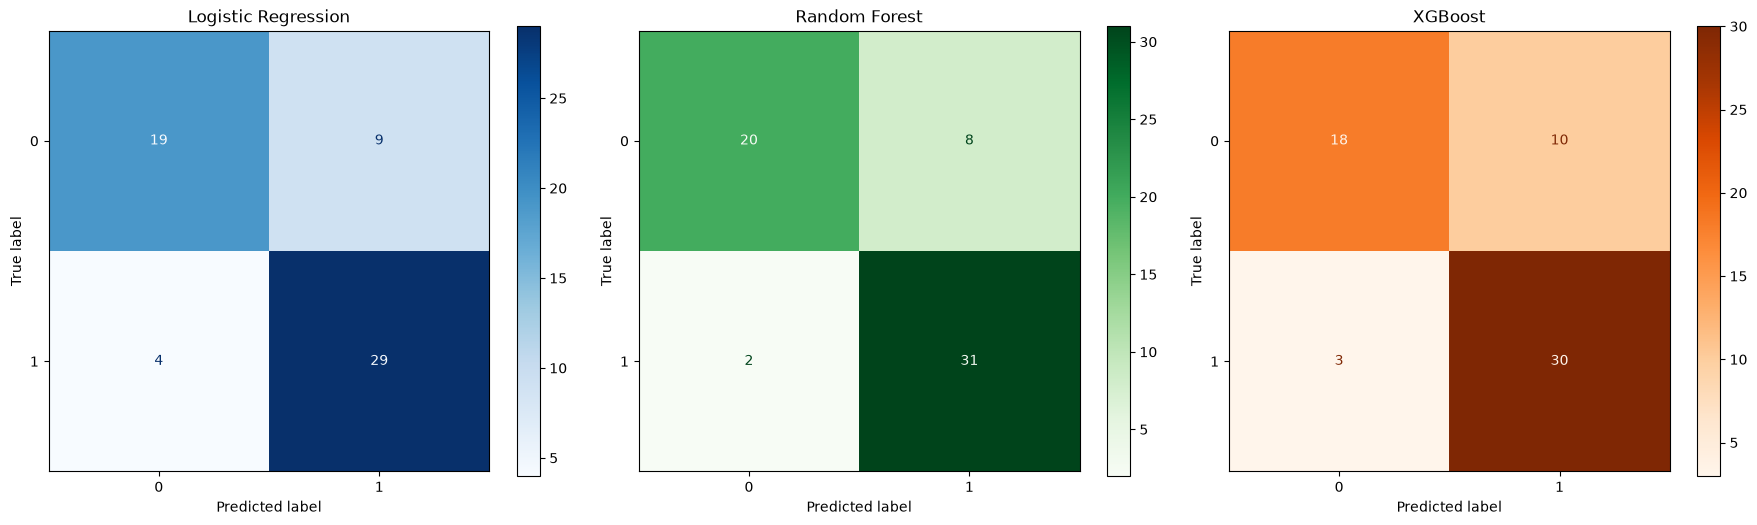

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

# Random Forest Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

# XGBoost Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[2], cmap='Oranges')
axes[2].set_title('XGBoost')

plt.tight_layout()
plt.show()